# Caio Vasconcelos Silva Andrade

## Análise Comparativa de Algoritmos de Otimização

### Introdução

Criei este notebook como atividade final de Busca e Otimização. Resuidamente vou. mostrar uma **análise comparativa e experimental de diversos algoritmos de otimização metaheurística** que foram mostrados em sala de aula pelo professor Andre!. Resumidamente eu ja vinha fazendo isso so que para cada algoritmo um notebook individual e comparando com o modelo anterior...ai agora so fiz juntar tudo e realizar as analises.

Os algoritmos:

- **Hill Climbing (HC)**: Busca local gulosa e determinística
- **Simulated Annealing (SA)**: Busca local com aceitação probabilística de movimentos inferiores
- **Algoritmos Genéticos (AG)**: Abordagem evolutiva baseada em seleção natural
- **Particle Swarm Optimization (PSO)**: Inteligência de enxame inspirada no comportamento coletivo


**Cada algoritmo será explicado testado nas funções benchmark e depois comparados!**

### Funções Benchmark

- **Sphere**: Função convexa e bem simples - ótima para avaliar convergência rápida
- **Ackley**: Função complexa e multimodal CHEIA de minimos locais, ideal para testar a capacidade de escapar de local minimum!

Essa são as funções onde vamos "rodar" nosso algoritmo e esparamos que ele chegue no minimo GLOBAL (Vulgo 0, no caso dessas duas funções).

---

### Metodologia

Para garantir uma comparação **justa** entre os algoritmos, eles foram testados sob as seguintes condições (Sugeridas/exigidas pelo professor):

#### Configuração de Teste

| Parâmetro | Valor |
|-----------|-------|
| **Dimensão** | 10 variáveis de decisão |
| **Intervalo de Busca** | [-100, 100] para cada dimensão |
| **Número de Execuções** | 20 rodadas independentes |
| **Avaliações** | ~50.000 avaliações da função objetivo por execução |

Explicando basicamente isso aqui, é o X (vetor) com 10 variavies continuas de -100 a 100 gerando um espáco de busca BEM GRANDE. Ou seja, ele vai pegar esse vetor inicial ai e vai tentar otimizar os X para que eles joguem o resultado da função benchmark em 0! (Isso para ackley e sphere)

#### Detalhes da Experimentação

- **Espaço**: O intervalo [-100, 100] em 10 dimensões cria um espaço contínuo desafiador com 10²⁰ possibilidades potenciais
- **Independência**: Cada algoritmo foi executado 20 vezes com inicializações aleatórias diferentes para obter resultados estatisticamente significativos
- **Avaliações**: O limite de ~50.000 avaliações garante que todos os algoritmos tenham recursos computacionais equivalentes
- **Análise Estatística**: Os resultados foram comparados utilizando testes não-paramétricos (Wilcoxon e Kruskal-Wallis)

# SPOILERS
Apenas o **PSO** provou seu valor contra o ACKLEY

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

## Sphere e Ackley

In [2]:
class Sphere:
    def __init__(self, n_var=10):
        self.n_var = n_var
        self.bounds = [-100, 100]
        
    def evaluate2(self, x):
        return np.sum(x**2)

    def evaluate(self, x):
        return np.sum((x - 0.5) ** 2)
    
class Ackley:
    def __init__(self, n_var=2, a=20, b=0.2, c=2*np.pi):
        self.n_var = n_var
        self.a = a
        self.b = b
        self.c = c
        self.bounds = [-100, 100]  # Domínio típico da função Ackley

    def evaluate(self, x):
        """Calcula o valor da função Ackley para um ponto x"""
        # Para lidar com múltiplos pontos (matriz) ou um único ponto (vetor)
        if x.ndim == 1:
            x = x.reshape(1, -1)
            
        sum_sq = np.sum(x**2)
        sum_cos = np.sum(np.cos(self.c * x))
        
        term1 = -self.a * np.exp(-self.b * np.sqrt(sum_sq / self.n_var))
        term2 = -np.exp(sum_cos / self.n_var)
        
        return term1 + term2 + self.a + np.exp(1)


In [3]:
# Criando instâncias dos problemas exemplo
sphere_2d = Sphere(n_var=2)
ackley_2d = Ackley(n_var=2)

In [4]:
# 2. Gerar dados para o gráfico da Sphere
x_s = np.linspace(-10, 10, 200)
y_s = np.linspace(-10, 10, 200)
X_s, Y_s = np.meshgrid(x_s, y_s)
# Calcula o Z avaliando cada ponto individualmente
Z_s = np.array([[sphere_2d.evaluate(np.array([x, y])) for x in x_s] for y in y_s])

# 3. Gerar dados para o gráfico da Ackley
# Usamos um intervalo maior para ver a "bacia" central e a área externa
x_a = np.linspace(-32, 32, 200)
y_a = np.linspace(-32, 32, 200)
X_a, Y_a = np.meshgrid(x_a, y_a)
# Calcula o Z avaliando cada ponto individualmente
Z_a = np.array([[ackley_2d.evaluate(np.array([x, y])) for x in x_a] for y in y_a])

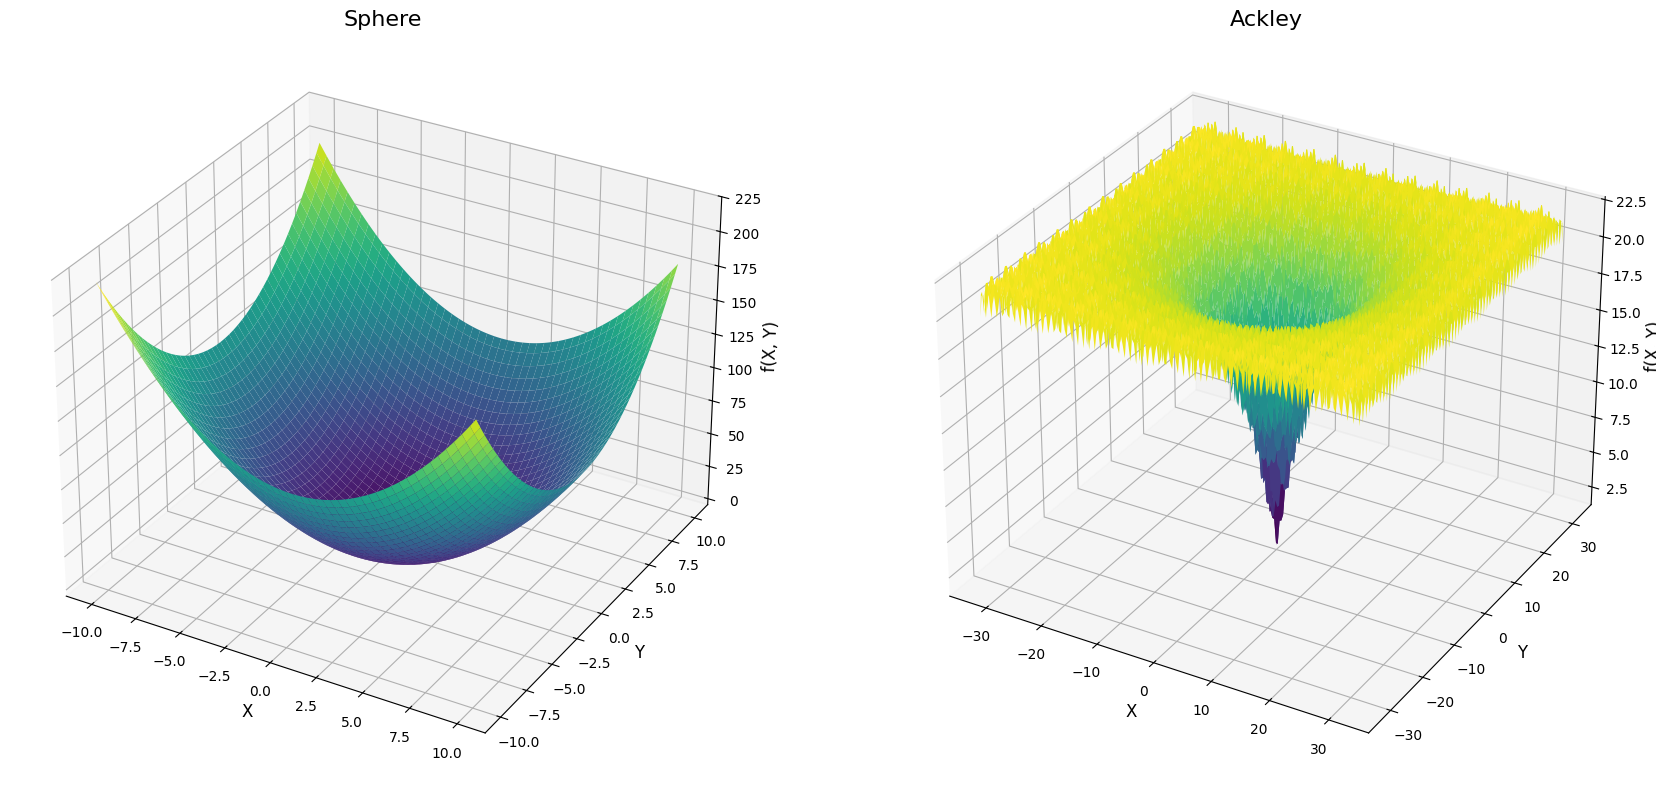

In [5]:
fig = plt.figure(figsize=(18, 8))

# Subplot para a Sphere
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_s, Y_s, Z_s, cmap='viridis', edgecolor='none')
ax1.set_title('Sphere', fontsize=16)
ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('Y', fontsize=12)
ax1.set_zlabel('f(X, Y)', fontsize=12)

# Subplot para a Ackley
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_a, Y_a, Z_a, cmap='viridis', edgecolor='none')
ax2.set_title('Ackley', fontsize=16)
ax2.set_xlabel('X', fontsize=12)
ax2.set_ylabel('Y', fontsize=12)
ax2.set_zlabel('f(X, Y)', fontsize=12)

plt.tight_layout()
plt.show()

# Hill Climbing

## Fundamentação Teórica

Hill Climbing é um algoritmo de busca local guloso que explora o espaço de soluções em direção a uma solução melhor (Min ou Max). O algoritmo funciona avaliando vizinhos da solução atual e aceitando apenas aqueles que melhoram o valor da função objetivo.

#### Usei como base/guia: [Geeks for Geeks Intro to hill climbing](https://www.geeksforgeeks.org/artificial-intelligence/introduction-hill-climbing-artificial-intelligence/)

## Tweak

O tweak serve como uma perturbação probabilística que cria pequenas variações de uma solução candidata. Este operador é fundamental para a exploração do espaço de busca local. Ele gera um pertubação para que possamos avaliar se essa pertubação gerou um resultado "melhor". O Guia que utilizei do geeks for geeks usa um tweak e o outro tweak utilizado retirei do livro que estamos utilizando.

No livro Essential temos duas abordagens:
1. **Aleatória**: Gera um vetor completamente aleatorio (Dentro dos limites estabelecidos -100 e 100)
2. **Probabilidade**: Faz o tweak no vetor dentro dos limites (-100 e 100) passando por uma probabilidade de ele fazer ou nao o tweak

O tweak do livro é a abordagem que usa **Probabilidade** que é oque vamos usar!

In [6]:
def bounded_uniform_convolution(v, p=1, r=10, min_val=-100, max_val=100):
    tweaked = v.copy()
    for i in range(len(tweaked)):
        if np.random.random() <= p:  # Probabilidade p de modificar este elemento
            while True:
                noise = np.random.uniform(-r, r)  # Ruído entre -r e r
                new_value = tweaked[i] + noise
                if min_val <= new_value <= max_val:  # Verifica limites
                    tweaked[i] = new_value
                    break
    return tweaked

In [7]:
def hill_climbing(func, initial, max_evaluations=50000, step_size=10, p = 0.9):
    current = initial.copy() # Faz uma copia do vetor X inicial
    current_eval = func.evaluate(current) # Ele vai vai rodar a funcao (No caso da esfere ele vai somar o quadrado dos elementos do vetor X)
    evaluations = 1 # Contador de avaliações
    history = [current_eval] # Histórico de avaliações (Apenas para fins de voltar depois e avaliar)

    # Enquanto houver avaliações disponíveis (For menos que o valor que definimos)
    while evaluations < max_evaluations:
        # CORREÇÃO: Gerar múltiplos vizinhos usando bounded_uniform_convolution
        neighbors = [bounded_uniform_convolution(current, p=p, r=step_size, min_val=func.bounds[0], max_val=func.bounds[1])] #for _ in range(20)]  # Gera 20 vizinhos
        neighbor_evals = [func.evaluate(n) for n in neighbors] # Roda a funcao
        evaluations += len(neighbors) # Atualiza o contador de avaliações (Agora são 20 vizinhos por iteração)
        best_idx = np.argmin(neighbor_evals) # Minimização (queremos o menor valor da função) (Ele retorna o índice do melhor vizinho (argmin))
        
        if neighbor_evals[best_idx] < current_eval: # Se encontrarmos um vizinho melhor
            current = neighbors[best_idx] # Atualiza o ponto atual
            current_eval = neighbor_evals[best_idx] # Atualiza a avaliação atual
            history.append(current_eval) # Adiciona a nova avaliação ao histórico
        # else: # Se não encontrarmos um vizinho melhor, reduzimos o passo
        #     step_size *= 0.90
        #     if step_size < 0.001:  # Critério mais rigoroso
        #         break  # Para se o passo ficar muito pequeno

    return current, current_eval, history # Current é o melhor ponto encontrado, current_eval é seu valor e history é o histórico de avaliações

### Sphere

In [8]:
sphere = Sphere(n_var=10)
resultados_sphere = [] # Lista de resultados_sphere2

for i in range(20):
    X = np.random.uniform(-100, 100, sphere.n_var) # Esse é nosso X
    a,b,c = hill_climbing(sphere, X, step_size=0.5, p=0.1)
    resultados_sphere.append(b)

    # Tire o comentário para ver os resultados de cada rodada
    #print(f"Rodada {i+1} tivemos um valor minimizado de {b:.5f} \n Com um vetor minimizado de: \n{a}")

min_value = min(resultados_sphere)
print(f"\nO melhor valor minimizado que conseguimos foi {min_value} da rodada {resultados_sphere.index(min_value) + 1}")


O melhor valor minimizado que conseguimos foi 3.774760877672165e-07 da rodada 9


### Ackley

In [9]:
ack = Ackley(n_var=10)
resultados_ack = [] # Lista de resultados_ack2

for i in range(20):
    X = np.random.uniform(-100, 100, ack.n_var) # Esse é nosso X
    a,b,c = hill_climbing(ack, X, p=0.5, step_size=10)
    resultados_ack.append(b)

    # Tire o comentário para ver os resultados de cada rodada
    #print(f"Rodada {i+1} tivemos um valor minimizado de {b}")

print(f"\nO melhor valor minimizado que conseguimos foi {min(resultados_ack)}")


O melhor valor minimizado que conseguimos foi 19.999405887248795


----------

# Simulated Annealing

Simulated Annealing (SA) pode ser visto como uma evolução do Hill Climbing que inclui um mecanismo para aceitar soluções "inferiores" de forma probabilística, e não apenas soluções melhores como no Hill Climbing tradicional.

A principal diferença está justamente na aceitação probabilística de movimentos que pioram a solução, o que permite ao algoritmo escapar de ótimos locais - algo que o Hill Climbing não consegue fazer por não permitir "passos para baixo". 

## Temperatura
**Temperatura:** Quando a temperatura está alta, o algoritmo se comporta mais como um "random walk", aceitando muitas soluções piores para explorar amplamente o espaço de soluções. Conforme a temperatura diminui, ele passa a se comportar cada vez mais como um Hill Climbing, focando na exploração de regiões promissoras. 

Este comportamento dinâmico é exatamente o que torna o Simulated Annealing melhor para problemas complexos com muitos ótimos locais, enquanto o Hill Climbing tende a ficar preso no primeiro ótimo local que encontra. 

## Formula
Uma observação técnica importante: a probabilidade de aceitar uma solução pior é geralmente calculada usando a **fórmula de Metropolis:** exp(-ΔE/T), onde ΔE é a degradação da solução e T é a temperatura atual. Essa função de aceitação probabilística é o coração do algoritmo.

## Resumo da Temperatura
### Fase 1: Alta Temperatura
Quando **T é alta**, o algoritmo se comporta como um **"random walk"** (caminhada aleatória):
- Aceita muitas soluções piores
- Explora amplamente o espaço de soluções
- Maior probabilidade de escapar de ótimos locais

### Fase 2: Temperatura Decrescente
Conforme **T diminui gradualmente**, o comportamento transita:
- Reduz a aceitação de soluções piores
- Passa a se comportar mais como Hill Climbing
- Foca na exploração de regiões promissoras

### Fase 3: Baixa Temperatura
Quando **T é muito baixa**:
- Funciona praticamente como Hill Climbing puro
- Aceita apenas melhorias significativas
- Converge para a melhor solução encontrada

In [1]:
def simulated_annealing(func, initial, max_evaluations=50000, initial_temp=1000, cooling_rate=0.99, min_temp=0.001, step_size=10):
    current = initial.copy()
    current_eval = func.evaluate(current)
    T = initial_temp  # Temperatura atual (substitui o step_size como controlador da busca)
    evaluations = 1
    history = [current_eval]

    while T > min_temp and evaluations < max_evaluations: # Se T ainda for mais que a temperatura minima e ainda tivermos avaliacoes
        # 1. GERE APENAS UM VIZINHO (Funcao tweak do hill climbing normal)
        neighbor = bounded_uniform_convolution(current, p=0.9, r=step_size,  min_val=func.bounds[0], max_val=func.bounds[1])
        neighbor_eval = func.evaluate(neighbor)
        evaluations += 1

        # 2. CALCULE A DIFERENÇA DE QUALIDADE (Entre a nova gerada do tweak e a atual, se )
        # Para minimização: se delta < 0 = melhoria (Pq saimos de um valor maior para um menor)
        # Se o novo for menor, entao o antigo é maior, vamos obter um valor negativo
        delta = neighbor_eval - current_eval  

        # 3. ACEITE OU REJEITE COM BASE NA TEMPERATURA
        if delta < 0:  # Sempre aceita soluções melhores (como Hill Climbing) (Como comentei, ele fica negativo)
            current = neighbor
            current_eval = neighbor_eval
            history.append(current_eval)
        else:  # Se por um acaso ele nao ficar negativo (Foi pior) aceita soluções piores com probabilidade controlada pela temperatura
            acceptance_prob = np.exp(-delta / T)  # Quanto maior T, maior a chance de aceitar, vamos ter um delta positivo (Ja que ele passo pelo primeiro if) e esse delta positivo vai ser divido por T
            if np.random.rand() < acceptance_prob: # Se o acceptance ai for maior que um numero aleatorio entre 0 e 1, nos aceitamos o ruim
                current = neighbor
                current_eval = neighbor_eval
                history.append(current_eval)

        # 4. RESFRIA A TEMPERATURA
        T *= cooling_rate  # Reduz a temperatura baseado no cooling_rate (não depende de melhoria)

    return current, current_eval, history

In [11]:
X = np.random.uniform(-100, 100, sphere.n_var) # Esse é nosso X
print(sphere.evaluate(X))
a,b,c = simulated_annealing(sphere, X)
b

23698.508337108273


np.float64(84.20811313510085)

In [12]:
sphere = Sphere(n_var=10)
resultados_simulated = [] # Lista de resultados_simulated

for i in range(20):
    X = np.random.uniform(-100, 100, sphere.n_var) # Esse é nosso X
    a,b,c = simulated_annealing(sphere, X, step_size=0.1, cooling_rate=0.999)
    resultados_simulated.append(b)

    print(f"Rodada {i+1} tivemos um valor minimizado de {b:.5f} \n Com um vetor minimizado de: \n{a}")

min_value = min(resultados_simulated)
print(f"\nO melhor valor minimizado que conseguimos foi {min_value} da rodada {resultados_simulated.index(min_value) + 1}")

Rodada 1 tivemos um valor minimizado de 0.00930 
 Com um vetor minimizado de: 
[0.4835394  0.46137129 0.50828029 0.46243979 0.43347759 0.47773945
 0.51060216 0.50398987 0.4767682  0.52159246]
Rodada 2 tivemos um valor minimizado de 0.00842 
 Com um vetor minimizado de: 
[0.5107649  0.50983724 0.50213717 0.52138416 0.45956527 0.50126414
 0.48428266 0.52977878 0.567172   0.47853366]
Rodada 3 tivemos um valor minimizado de 0.01044 
 Com um vetor minimizado de: 
[0.50875902 0.4923078  0.54693539 0.50331823 0.48177983 0.49155423
 0.50318111 0.54125043 0.46556313 0.43077975]
Rodada 4 tivemos um valor minimizado de 0.00580 
 Com um vetor minimizado de: 
[0.49326983 0.53348836 0.47057095 0.49398539 0.50506427 0.50846236
 0.48470842 0.4474433  0.49172421 0.47620121]
Rodada 5 tivemos um valor minimizado de 0.00554 
 Com um vetor minimizado de: 
[0.50975499 0.53950827 0.52912763 0.5044526  0.52358843 0.47991804
 0.54239413 0.49133656 0.49077729 0.4901641 ]
Rodada 6 tivemos um valor minimizado de 

In [13]:
X = np.random.uniform(-100, 100, ack.n_var) # Esse é nosso X
print(ack.evaluate(X))
a2,b2,c2 = simulated_annealing(ack, X)
b2

21.771979431628036


np.float64(20.595586748315547)

In [14]:
ack = Ackley(n_var=10)
resultados_simulated2 = [] # Lista de resultados_simulated2

for i in range(20):
    X = np.random.uniform(-100, 100, ack.n_var) # Esse é nosso X
    a2,b2,c2 = simulated_annealing(ack, X, step_size=15, initial_temp=10000, cooling_rate=0.9995, min_temp=0.001)
    resultados_simulated2.append(b2)

    print(f"Rodada {i+1} tivemos um valor minimizado de {b2}")

print(f"\nO melhor valor minimizado que conseguimos foi {min(resultados_simulated2)}")

Rodada 1 tivemos um valor minimizado de 20.536022695950233
Rodada 2 tivemos um valor minimizado de 20.431031905598974
Rodada 3 tivemos um valor minimizado de 20.47234679423219
Rodada 4 tivemos um valor minimizado de 20.486994232205074
Rodada 5 tivemos um valor minimizado de 20.242892154952933
Rodada 6 tivemos um valor minimizado de 20.520785846727403
Rodada 7 tivemos um valor minimizado de 20.45610789923179
Rodada 8 tivemos um valor minimizado de 20.264670055837254
Rodada 9 tivemos um valor minimizado de 20.470516534928276
Rodada 10 tivemos um valor minimizado de 20.607297766740793
Rodada 11 tivemos um valor minimizado de 20.232180123588027
Rodada 12 tivemos um valor minimizado de 20.519370886426525
Rodada 13 tivemos um valor minimizado de 20.48171557020823
Rodada 14 tivemos um valor minimizado de 20.506972529920898
Rodada 15 tivemos um valor minimizado de 20.442203256415365
Rodada 16 tivemos um valor minimizado de 20.446569571166535
Rodada 17 tivemos um valor minimizado de 20.49410926

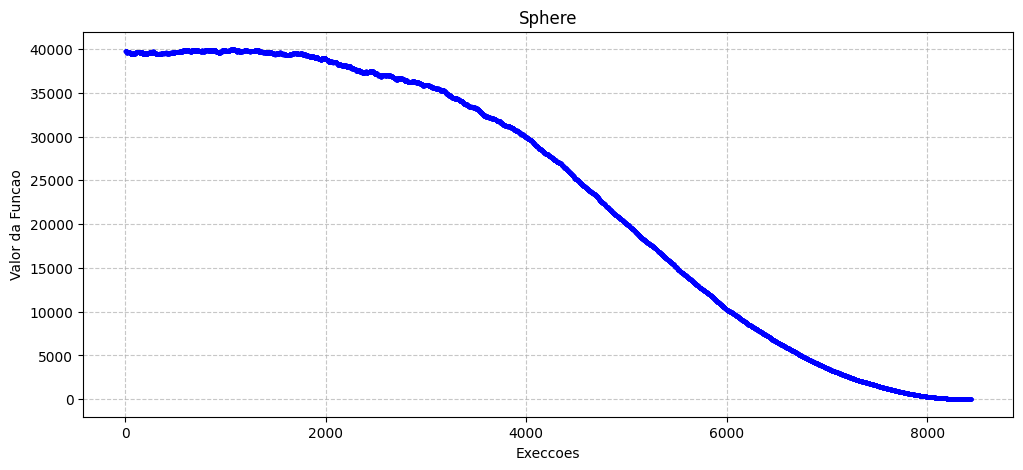

In [15]:
# Para Sphere (já funcionando)
plt.figure(figsize=(12, 5))

# Lembrando que c é o histórico de avaliações (DA ULTIMA RODADA OBVIAMENTE!!) (ISSO TUDO DO SIMULATED ANNEALING)
plt.plot(c, 'b-o', markersize=2)
plt.title('Sphere')
plt.xlabel('Execcoes')
plt.ylabel('Valor da Funcao')
plt.grid(True, linestyle='--', alpha=0.7)
#plt.yscale('log')  # Talvez eu precise ativar a escala aqui
plt.show()

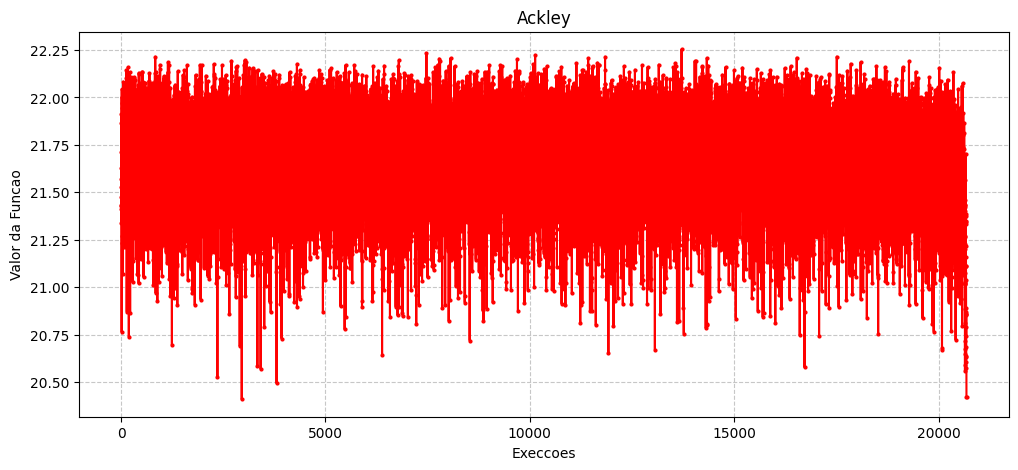

In [16]:
# # Para Ackley
plt.figure(figsize=(12, 5))

# Lembrando que c2 é o histórico de avaliações (DA ULTIMA RODADA OBVIAMENTE!!) (ISSO TUDO DO SIMULATED ANNEALING)
plt.plot(c2, 'r-o', markersize=2)  
plt.title('Ackley')
plt.xlabel('Execcoes')
plt.ylabel('Valor da Funcao')
plt.grid(True, linestyle='--', alpha=0.7)
#plt.yscale('linear')  # Talvez eu precise ativar a escala aqui

plt.show()

# Hyperparâmetros
### Sphere
- HC: step_size=0.5, p=0.1
- SA: step_size=0.1, cooling_rate=0.999, initial_temp = 1000

### Ackley
- HC: Tanto faz
- SA: Tanto faz

## Análise Estatística: Teste de Wilcoxon

### O que é?

O **Teste de Wilcoxon** é um teste não-paramétrico que compara **dois grupos de dados pareados** para determinar se há diferença estatisticamente significativa entre eles.

- **Não-paramétrico**: Não assume distribuição normal dos dados
- **Ideal para**: Comparar desempenho de dois algoritmos
- **Hipótese nula (H₀)**: Os dois grupos têm distribuições iguais

### Oque esperar
- Se **p-value < 0.05**: HC e SA têm desempenho significativamente diferente
- Se **p-value ≥ 0.05**: HC e SA têm desempenho estatisticamente equivalente

In [17]:
# Resultados sphere

resultados_sphere.sort(reverse=False)
resultados_simulated.sort(reverse=False)
display(resultados_sphere[:5])
display(resultados_simulated[:5])

[np.float64(3.774760877672165e-07),
 np.float64(4.7046921058985484e-07),
 np.float64(5.566767386372704e-07),
 np.float64(7.518890963079854e-07),
 np.float64(8.403031760402276e-07)]

[np.float64(0.0023722888678641154),
 np.float64(0.003571080594502877),
 np.float64(0.004601242948132427),
 np.float64(0.004772666374652585),
 np.float64(0.005538128277494019)]

In [18]:
# Resultados ACkley

resultados_ack.sort(reverse=False)
resultados_simulated2.sort(reverse=False)
display(resultados_ack[:5])
display(resultados_simulated2[:5])

[np.float64(19.999405887248795),
 np.float64(20.00159945967355),
 np.float64(20.00178575242024),
 np.float64(20.001993614885986),
 np.float64(20.00227553141025)]

[np.float64(20.232180123588027),
 np.float64(20.242892154952933),
 np.float64(20.264670055837254),
 np.float64(20.387054352537273),
 np.float64(20.419979920722113)]

In [19]:
from scipy import stats
print(f"Sphere: {stats.wilcoxon(resultados_sphere,resultados_simulated)}")
print(f"Ackley: {stats.wilcoxon(resultados_ack,resultados_simulated2)}")

Sphere: WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(1.9073486328125e-06))
Ackley: WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(1.9073486328125e-06))


## Resultados
1. O hill climbing (HC) para funções relativamente simples é muito bom! (Como a sphere)

2. O Simulated Annealing (SA) para funções simples é bom tambem...mas talvez ele brilhe em funções um pouco mais complexas! Não tão simples como a sphere, mas também não tão complexas como o Ackley! (Talvez o fato de estarmos com um X de 10D e de -100 a 100...testei ele com um vetor de 3 e 2 e ele foi BEM melhor)

3. Infelizmente nenhum dos dois vai funcionar na Ackley! 
------------

# Genetic Algorithm

### Meta-heurística Inspirada na Evolução Natural

Os **Algoritmos Genéticos (AGs)**, são uma classe de algoritmos de otimização e busca baseada nos princípios da genética e da seleção natural.

Diferente de estratégias como o *Hill Climbing*, que operam sobre uma única solução, os Algoritmos Genéticos trabalham com uma **população** de soluções candidatas. Essa população evolui ao longo de gerações através de mecanismos como **seleção**, **cruzamento (crossover)** e **mutação**, convergindo para uma solução ótima para o problema.

### Parametros

* **Mutação:** A ideia de "tweak" (pequena modificação) que exploramos no Hill Climbing encontra um paralelo direto no operador de **mutação**.

* **Elitism**: O elitismo **preserva os melhores indivíduos** de uma geração para a próxima

* **Tournament Selection:** A seleção por torneio escolhe os melhores indivíduos da população para reprodução
1. Seleciona `t` indivíduos aleatoriamente da população
2. Compara seus valores de fitness
3. Retorna o melhor indivíduo encontrado

* **Two-Point Crossover:** O cruzamento combina material genético de dois pais para gerar descendentes


In [20]:
# Algoritmo 32 do livro (Esqueci o nome): Seleção por Torneio
# População P, função de fitness Fitness, tamanho do torneio t
# Saida: Indivíduo selecionado Best
# t: tamanho do torneio (binário por padrão e lembro que o professor comentou que é bom o t = 2).
# Peguei a explicação do site: https://www.geeksforgeeks.org/dsa/tournament-selection-ga/
def tournament_selection(population, fitness_values, t=2):
    # indivíduo pego aleatoriamente de P
    best_index = random.randint(0, len(population) - 1)
    
    # for i from 2 to t do
    for _ in range(1, t):
        # indivíduo pego aleatoriamente de P
        next_index = random.randint(0, len(population) - 1)
        # Fitness(Next) > Fitness(Best) then
        if fitness_values[next_index] > fitness_values[best_index]:
            # Best <- Next
            best_index = next_index
            
    # Retorna o melhor indivíduo encontrado   
    return population[best_index]

In [21]:
# Two-Point Crossover
# Realiza o cruzamento de dois pontos.
# Ele recebe dois pais (parent1 e parent2) e retorna dois filhos (child1 e child2)
# Peguei esse código do site: https://www.geeksforgeeks.org/machine-learning/crossover-in-genetic-algorithm/
def two_point_crossover(parent1, parent2):
    """
    Realiza o cruzamento de dois pontos.
    """
    size = len(parent1)
    # Garante que os pontos de corte sejam diferentes e ordenados
    p1, p2 = sorted(random.sample(range(size), 2))
    
    # Cria os filhos trocando o segmento entre os pontos de corte
    child1 = np.concatenate([parent1[:p1], parent2[p1:p2], parent1[p2:]])
    child2 = np.concatenate([parent2[:p1], parent1[p1:p2], parent2[p2:]])
    
    return child1, child2


In [22]:
# É a função que cria um indivíduo aleatório dentro dos limites
# Antes eu fazia hardcoded np.random.uniform(-100, 100, dim)
# Mas ai eu posso usar essa função para qualquer problema, desde que eu passe os limites
# E posso usar essa função para criar a população inicial
def create_random_individual(dim, min_val, max_val):
    return np.random.uniform(min_val, max_val, dim)

In [23]:
# Algoritmo 33 do livro: Algoritmo Genético
# Problema P, tamanho da população popsize, número de elites n_elites,
# número máximo de avaliações max_evals, tamanho do torneio tournament_size
# Ele usa o tweak bounded_uniform_convolution (Que é o mesmo do hill climbing e do simulated annealing)
def genetic_algorithm(problem,popsize=100, n_elites=10, max_evals=50000, tournament_size=2):

    dim = problem.n_var
    min_val, max_val = problem.bounds
    eval_count = 0
    
    population = [create_random_individual(dim, min_val, max_val) for _ in range(popsize)]
    # if initial is not None:
    #     population = initial

    best_overall_individual = None
    # Fitness é maximizado, então começamos com -infinito
    best_overall_fitness = -np.inf

    while eval_count < max_evals:
        fitness_values = []
        for ind in population:
            # IMPORTANTE: Usamos o negativo porque o AG maximiza e o problema é de minimização
            fitness_values.append(-problem.evaluate(ind))
            eval_count += 1
            if eval_count >= max_evals:
                break
        
        current_best_fitness_idx = np.argmax(fitness_values)
        if fitness_values[current_best_fitness_idx] > best_overall_fitness:
            best_overall_fitness = fitness_values[current_best_fitness_idx]
            best_overall_individual = population[current_best_fitness_idx]
        
        sorted_indices = np.argsort(fitness_values)[::-1]
        next_population = [population[i] for i in sorted_indices[:n_elites]]

        num_children_to_create = popsize - n_elites
        for _ in range(num_children_to_create // 2):
            parent_a = tournament_selection(population, fitness_values, t=tournament_size)
            parent_b = tournament_selection(population, fitness_values, t=tournament_size)
            child_a, child_b = two_point_crossover(parent_a, parent_b)
            next_population.append(bounded_uniform_convolution(child_a, min_val=min_val, max_val=max_val))
            next_population.append(bounded_uniform_convolution(child_b, min_val=min_val, max_val=max_val))

        population = next_population[:popsize]

    # Retorna o melhor indivíduo e o valor da função OBJETIVO (não o fitness)
    # Por isso, invertemos o sinal de volta
    return best_overall_individual, -best_overall_fitness

In [24]:
sphere_problem = Sphere(n_var=10)
resultados_ag_sphere = []

for i in range(20):
    # A chamada ao AG não precisa de um X inicial, ele cria a própria população
    best_vector, best_value = genetic_algorithm(problem=sphere_problem, popsize=200, n_elites=10)
    resultados_ag_sphere.append(best_value)
    # Imprimindo no formato que você gosta
    print(f"Rodada {i+1} tivemos um valor minimizado de {best_value:.5f}")

Rodada 1 tivemos um valor minimizado de 42.53067
Rodada 2 tivemos um valor minimizado de 23.13492
Rodada 3 tivemos um valor minimizado de 37.19648
Rodada 4 tivemos um valor minimizado de 40.12541
Rodada 5 tivemos um valor minimizado de 46.72481
Rodada 6 tivemos um valor minimizado de 60.01001
Rodada 7 tivemos um valor minimizado de 47.93233
Rodada 8 tivemos um valor minimizado de 73.99898
Rodada 9 tivemos um valor minimizado de 73.22663
Rodada 10 tivemos um valor minimizado de 70.57230
Rodada 11 tivemos um valor minimizado de 58.65686
Rodada 12 tivemos um valor minimizado de 87.43075
Rodada 13 tivemos um valor minimizado de 55.58822
Rodada 14 tivemos um valor minimizado de 62.94506
Rodada 15 tivemos um valor minimizado de 48.73622
Rodada 16 tivemos um valor minimizado de 50.81536
Rodada 17 tivemos um valor minimizado de 79.12708
Rodada 18 tivemos um valor minimizado de 59.26713
Rodada 19 tivemos um valor minimizado de 67.98376
Rodada 20 tivemos um valor minimizado de 56.90570


In [25]:
ackley_problem = Ackley(n_var=10)
resultados_ag_ackley = []

for i in range(20):
    best_vector, best_value = genetic_algorithm(problem=ackley_problem,popsize=200, n_elites=10)
    resultados_ag_ackley.append(best_value)
    print(f"Rodada {i+1} tivemos um valor minimizado de {best_value:.5f}")

Rodada 1 tivemos um valor minimizado de 20.41660
Rodada 2 tivemos um valor minimizado de 20.35054
Rodada 3 tivemos um valor minimizado de 20.44113
Rodada 4 tivemos um valor minimizado de 20.38265
Rodada 5 tivemos um valor minimizado de 20.50160
Rodada 6 tivemos um valor minimizado de 20.34735
Rodada 7 tivemos um valor minimizado de 10.78043
Rodada 8 tivemos um valor minimizado de 20.40114
Rodada 9 tivemos um valor minimizado de 20.49288
Rodada 10 tivemos um valor minimizado de 20.29266
Rodada 11 tivemos um valor minimizado de 20.46125
Rodada 12 tivemos um valor minimizado de 20.29283
Rodada 13 tivemos um valor minimizado de 20.49229
Rodada 14 tivemos um valor minimizado de 8.44528
Rodada 15 tivemos um valor minimizado de 20.42321
Rodada 16 tivemos um valor minimizado de 20.32900
Rodada 17 tivemos um valor minimizado de 20.42173
Rodada 18 tivemos um valor minimizado de 20.44442
Rodada 19 tivemos um valor minimizado de 20.50710
Rodada 20 tivemos um valor minimizado de 20.50594


### KRUSKAL-WALLIS
O **Teste de Kruskal-Wallis** é outro teste estatístico não-paramétrico que generaliza o Teste de Wilcoxon para **comparar três ou mais grupos independentes**. 
Esqueci de comentar la em cima, os testes não paramétricos **NÃO ASSUMEM QUE OS DADOS SEGUEM UMA DISTRIBUIÇÃO NORMAL!!**

Não vou me estender muito pois não me aprofundei nos testes estatísticos.


In [26]:
print(stats.kruskal(resultados_sphere,resultados_simulated,resultados_ag_sphere))

KruskalResult(statistic=np.float64(52.459016393442624), pvalue=np.float64(4.061339800128413e-12))


In [27]:
print(stats.kruskal(resultados_ack,resultados_simulated2,resultados_ag_ackley))

KruskalResult(statistic=np.float64(34.35049180327866), pvalue=np.float64(3.4744453067304555e-08))


/var/folders/q3/h9m1yh814n3fp5jc3qztrj180000gn/T/ipykernel_12997/691316638.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([resultados_sphere, resultados_simulated, resultados_ag_sphere], labels=['Hill Climbing', 'Simulated Annealing', 'AG'])
/var/folders/q3/h9m1yh814n3fp5jc3qztrj180000gn/T/ipykernel_12997/691316638.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([resultados_ack, resultados_simulated2, resultados_ag_ackley], labels=['Hill Climbing', 'Simulated Annealing', 'AG'])


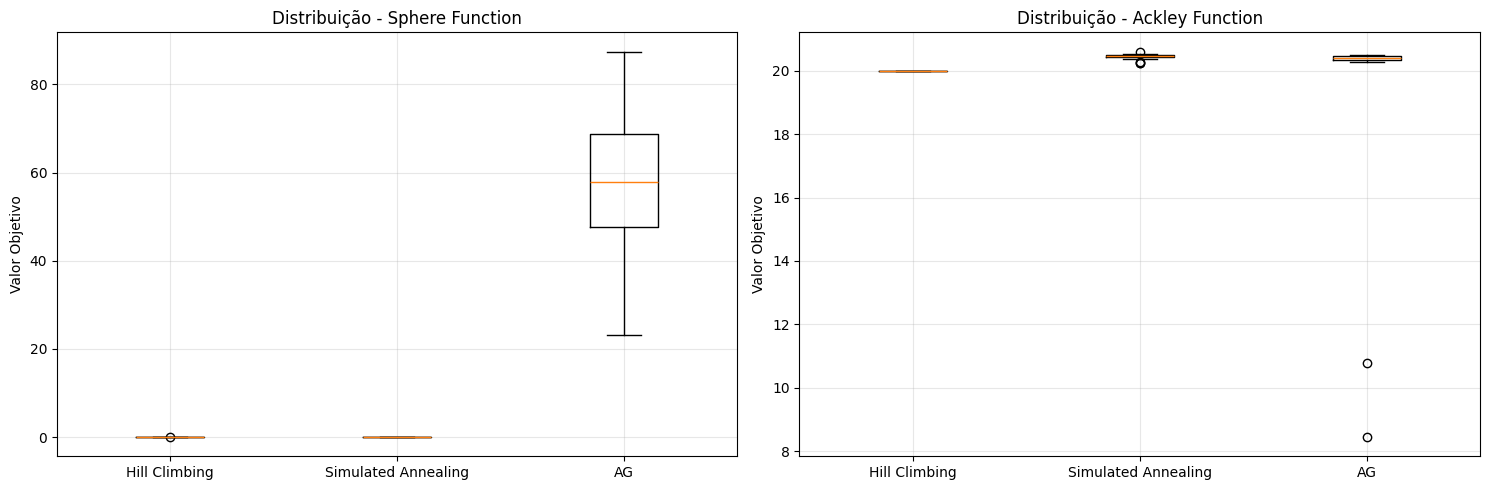

In [28]:
# Criar boxplots para visualizar a distribuição dos resultados
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot para Sphere
axes[0].boxplot([resultados_sphere, resultados_simulated, resultados_ag_sphere], labels=['Hill Climbing', 'Simulated Annealing', 'AG'])
axes[0].set_title('Distribuição - Sphere Function')
axes[0].set_ylabel('Valor Objetivo')
axes[0].grid(True, alpha=0.3)

# Boxplot para Ackley
axes[1].boxplot([resultados_ack, resultados_simulated2, resultados_ag_ackley], labels=['Hill Climbing', 'Simulated Annealing', 'AG'])
axes[1].set_title('Distribuição - Ackley Function')
axes[1].set_ylabel('Valor Objetivo')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---------
# PSO & DE Algorithms
## Acabei escolhendo o PSO
### Eu achei esse artigo que usei como base para os parametros! [LINK](https://www.researchgate.net/profile/Mohamed-Mourad-Lafifi/post/Which-is-the-best-swarm-size-in-PSO/attachment/5b5b6f85b53d2f89289c14e1/AS%3A653084896288769%401532718981208/download/Good+Parameters+for+Particle+Swarm+Optimization.pdf)

### Particle Swarm Optimization (PSO)

Inspirado no comportamento coletivo de bandos de pássaros PSO:

* Trabalha com uma população de partículas que navegam pelo espaço de busca
* Cada partícula ajusta sua trajetória baseando-se em:
    * Sua melhor experiência individual
    * A melhor experiência do coletivo

Utiliza velocidade e inércia para direcionar a exploração (Ainda não entendi muito isso aqui)

### Differential Evolution (DE)

Foca em estratégias de mutação baseadas em diferenças entre soluções:

Opera através de operadores específicos:

* Mutação diferencial: Gera novos vetores combinando diferenças entre indivíduos
* Recombinação: Mistura componentes de vetores-mutação com vetores-alvo
* Seleção competitiva: Substitui a geração atual apenas se houver melhoria

### Base do PSO: https://medium.com/data-science/what-the-hell-is-particle-swarm-optimization-pso-simplest-explanation-in-python-be296fc3b1ab
### Base do Parameters para PSO: https://www.researchgate.net/profile/Mohamed-Mourad-Lafifi/post/Which-is-the-best-swarm-size-in-PSO/attachment/5b5b6f85b53d2f89289c14e1/AS%3A653084896288769%401532718981208/download/Good+Parameters+for+Particle+Swarm+Optimization.pdf

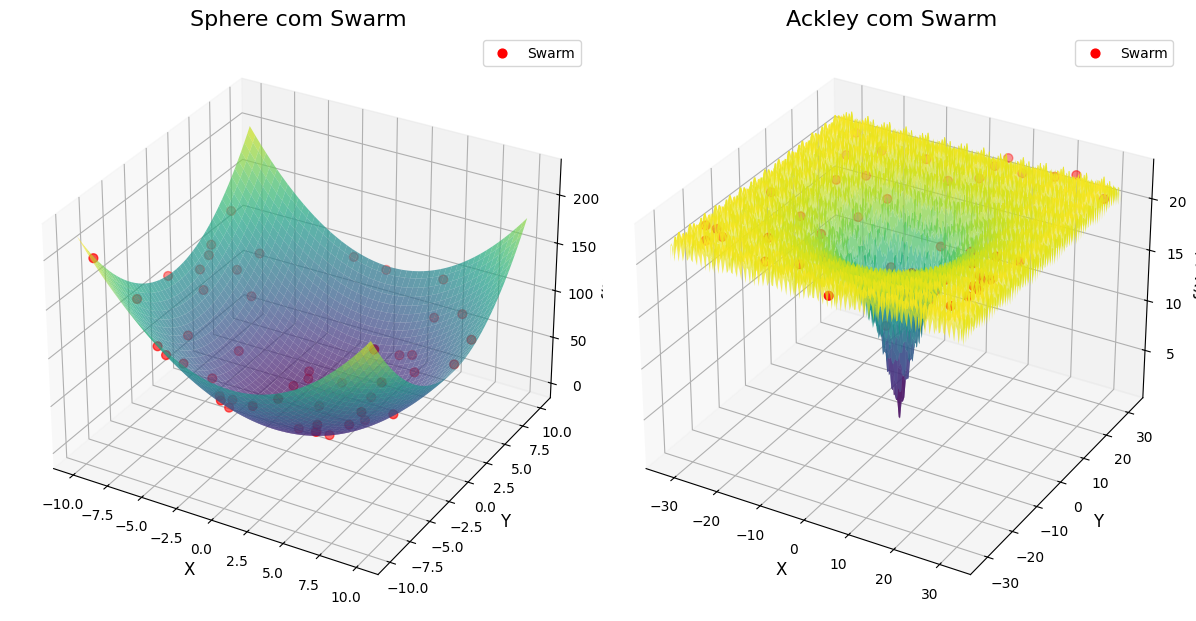

In [29]:
# Gerar o enxame (pontos aleatórios)
n_particles = 50
# Para a Sphere, no intervalo [-10, 10]
swarm_s_x = np.random.uniform(-10, 10, n_particles)
swarm_s_y = np.random.uniform(-10, 10, n_particles)
swarm_s_z = np.array([sphere_2d.evaluate(np.array([x, y])) for x, y in zip(swarm_s_x, swarm_s_y)])

# Para a Ackley, no intervalo [-32, 32]
swarm_a_x = np.random.uniform(-32, 32, n_particles)
swarm_a_y = np.random.uniform(-32, 32, n_particles)
swarm_a_z = np.array([ackley_2d.evaluate(np.array([x, y])) for x, y in zip(swarm_a_x, swarm_a_y)])

# 2. Plotar novamente com o enxame
fig = plt.figure(figsize=(12, 8))

# Subplot para a Sphere com enxame
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_s, Y_s, Z_s, cmap='viridis', edgecolor='none', alpha=0.7)
ax1.scatter(swarm_s_x, swarm_s_y, swarm_s_z, color='red', s=40, label='Swarm')
ax1.set_title('Sphere com Swarm', fontsize=16)
ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('Y', fontsize=12)
ax1.set_zlabel('f(X, Y)', fontsize=12)
ax1.legend()

# Subplot para a Ackley com enxame
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_a, Y_a, Z_a, cmap='viridis', edgecolor='none', alpha=0.7)
ax2.scatter(swarm_a_x, swarm_a_y, swarm_a_z, color='red', s=40, label='Swarm')
ax2.set_title('Ackley com Swarm', fontsize=16)
ax2.set_xlabel('X', fontsize=12)
ax2.set_ylabel('Y', fontsize=12)
ax2.set_zlabel('f(X, Y)', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

In [30]:
def particle_swarm_optimization(problem, n_particles=30, max_evals=50000, w=0.7, c1=1.5, c2=1.5):
    
    dim = problem.n_var
    min_val, max_val = problem.bounds
    eval_count = 0
    
    # Inicializa posições e velocidades das partículas
    positions = np.array([create_random_individual(dim, min_val, max_val) for _ in range(n_particles)])
    velocities = np.random.uniform(-abs(max_val - min_val) * 0.1, 
                                   abs(max_val - min_val) * 0.1, 
                                   (n_particles, dim))
    
    # Avalia posições iniciais
    fitness = np.array([problem.evaluate(pos) for pos in positions])
    eval_count += n_particles
    
    # Inicializa melhores posições individuais (pbest)
    pbest_positions = positions.copy()
    pbest_fitness = fitness.copy()
    
    # Inicializa melhor posição global (gbest)
    gbest_idx = np.argmin(pbest_fitness)
    gbest_position = pbest_positions[gbest_idx].copy()
    gbest_fitness = pbest_fitness[gbest_idx]
    
    # Loop principal
    while eval_count < max_evals:
        for i in range(n_particles):
            # Componentes aleatórios
            r1 = np.random.random(dim)
            r2 = np.random.random(dim)
            
            # Atualiza velocidade
            # v = w*v + c1*r1*(pbest - x) + c2*r2*(gbest - x)
            cognitive = c1 * r1 * (pbest_positions[i] - positions[i])
            social = c2 * r2 * (gbest_position - positions[i])
            velocities[i] = w * velocities[i] + cognitive + social
            
            # Atualiza posição
            positions[i] = positions[i] + velocities[i]
            
            # Aplica limites nas posições
            positions[i] = np.clip(positions[i], min_val, max_val)
            
            # Avalia nova posição
            current_fitness = problem.evaluate(positions[i])
            eval_count += 1
            
            # Atualiza pbest se necessário
            if current_fitness < pbest_fitness[i]:
                pbest_positions[i] = positions[i].copy()
                pbest_fitness[i] = current_fitness
                
                # Atualiza gbest se necessário
                if current_fitness < gbest_fitness:
                    gbest_position = positions[i].copy()
                    gbest_fitness = current_fitness
            
            if eval_count >= max_evals:
                break
    
    return gbest_position, gbest_fitness


In [31]:
# PSO para Sphere
sphere_pso = Sphere(n_var=10)
resultados_pso_sphere = []

for i in range(20):
    best_vector, best_value = particle_swarm_optimization(problem=sphere_pso, n_particles=30, max_evals=50000, w=0.7, c1=1.5, c2=1.5)
    resultados_pso_sphere.append(best_value)
    print(f"Rodada {i+1} tivemos um valor minimizado de {best_value:.5f}")

min_value = min(resultados_pso_sphere)
print(f"\nO melhor valor minimizado que conseguimos foi {min_value:.5f} da rodada {resultados_pso_sphere.index(min_value) + 1}")


Rodada 1 tivemos um valor minimizado de 0.00000
Rodada 2 tivemos um valor minimizado de 0.00000
Rodada 3 tivemos um valor minimizado de 0.00000
Rodada 4 tivemos um valor minimizado de 0.00000
Rodada 5 tivemos um valor minimizado de 0.00000
Rodada 6 tivemos um valor minimizado de 0.00000
Rodada 7 tivemos um valor minimizado de 0.00000
Rodada 8 tivemos um valor minimizado de 0.00000
Rodada 9 tivemos um valor minimizado de 0.00000
Rodada 10 tivemos um valor minimizado de 0.00000
Rodada 11 tivemos um valor minimizado de 0.00000
Rodada 12 tivemos um valor minimizado de 0.00000
Rodada 13 tivemos um valor minimizado de 0.00000
Rodada 14 tivemos um valor minimizado de 0.00000
Rodada 15 tivemos um valor minimizado de 0.00000
Rodada 16 tivemos um valor minimizado de 0.00000
Rodada 17 tivemos um valor minimizado de 0.00000
Rodada 18 tivemos um valor minimizado de 0.00000
Rodada 19 tivemos um valor minimizado de 0.00000
Rodada 20 tivemos um valor minimizado de 0.00000

O melhor valor minimizado qu

In [35]:
# PSO para Ackley
ackley_pso = Ackley(n_var=10)
resultados_pso_ackley = []

for i in range(20):
    best_vector, best_value = particle_swarm_optimization(problem=ackley_pso, n_particles=90, max_evals=50000, w=0.6571, c1=1.6319, c2=0.6239)
    resultados_pso_ackley.append(best_value)
    print(f"Rodada {i+1} tivemos um valor minimizado de {best_value:.5f}")

min_value = min(resultados_pso_ackley)
print(f"\nO melhor valor minimizado que conseguimos foi {min_value:.5f} da rodada {resultados_pso_ackley.index(min_value) + 1}")


Rodada 1 tivemos um valor minimizado de 20.07728
Rodada 2 tivemos um valor minimizado de 20.01372
Rodada 3 tivemos um valor minimizado de 0.00000
Rodada 4 tivemos um valor minimizado de 0.00000
Rodada 5 tivemos um valor minimizado de 0.00000
Rodada 6 tivemos um valor minimizado de 0.00000
Rodada 7 tivemos um valor minimizado de 0.00000
Rodada 8 tivemos um valor minimizado de 0.00000
Rodada 9 tivemos um valor minimizado de 20.02457
Rodada 10 tivemos um valor minimizado de 0.00000
Rodada 11 tivemos um valor minimizado de 20.11424
Rodada 12 tivemos um valor minimizado de 20.21362
Rodada 13 tivemos um valor minimizado de 0.00000
Rodada 14 tivemos um valor minimizado de 0.00000
Rodada 15 tivemos um valor minimizado de 0.00000
Rodada 16 tivemos um valor minimizado de 20.07347
Rodada 17 tivemos um valor minimizado de 0.00000
Rodada 18 tivemos um valor minimizado de 20.19550
Rodada 19 tivemos um valor minimizado de 20.12639
Rodada 20 tivemos um valor minimizado de 0.00000

O melhor valor minim

In [33]:
print(stats.kruskal(resultados_sphere,resultados_simulated,resultados_ag_sphere,resultados_pso_sphere))

KruskalResult(statistic=np.float64(75.2470532206215), pvalue=np.float64(3.2074176323880333e-16))


In [34]:
print(stats.kruskal(resultados_ack,resultados_simulated2,resultados_ag_ackley,resultados_pso_ackley))

KruskalResult(statistic=np.float64(48.61474343192773), pvalue=np.float64(1.5755762511659797e-10))


## Resultados
1. O PSO chegou sempre a 0 no Sphere (Obviamente)

2. Ja no Ackley o processo foi um pouco mais curioso!

    2.1 O parameters que usei foram de um artigo que achei sobre os melhores parametros para PSO a depender de alguns fatores (Como dimensão do seu problema) e com esses parametros ele consegui chegar a 0 varias vezes!

    2.2 Ja quando usei os parametros que usei "padrão" (Que usei no sphere) ele raramente chegou a 0!
------------